# 02 - Graph Convolutional Network (GCN)

The **GCN** (Kipf & Welling, 2017) is the GNN everyone meets first. It came from
spectral graph theory but boils down to a famously clean propagation rule:

$$ H^{(l+1)} = \sigma\!\left( \hat{A}\, H^{(l)}\, W^{(l)} \right),
   \qquad \hat{A} = \tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2},
   \qquad \tilde{A} = A + I $$

In words: **add self-loops** ($A+I$), then take a **degree-normalised average** of each
node's neighbourhood (including itself), multiply by a weight matrix, apply a
nonlinearity. The symmetric normalisation $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$
keeps feature scales stable and down-weights edges to high-degree hubs.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## Building A_hat by hand = what GCNConv does for you

Let's construct the normalised propagation matrix ourselves and confirm one
hand-rolled propagation step matches `torch_geometric.nn.GCNConv` with identity weights.

In [2]:
from torch_geometric.nn import GCNConv
data, gt = G.make_sbm_homophily(homophily=0.85, seed=1)

# Hand-built  A_hat = D^-1/2 (A+I) D^-1/2
n = data.num_nodes
A = torch.zeros(n, n); A[data.edge_index[0], data.edge_index[1]] = 1
A_tilde = A + torch.eye(n)
deg = A_tilde.sum(1)
Dinv = torch.diag(deg.pow(-0.5))
A_hat = Dinv @ A_tilde @ Dinv

manual = A_hat @ data.x                      # one propagation, identity weights
conv = GCNConv(data.num_features, data.num_features, bias=False)
torch.nn.init.eye_(conv.lin.weight)          # make it an identity map
pyg = conv(data.x, data.edge_index)
print("max |manual - GCNConv| =", (manual - pyg).abs().max().item(), " (~0 -> identical)")

max |manual - GCNConv| = 3.5762786865234375e-07  (~0 -> identical)


## GCN shines under homophily

GCN averages each neighbourhood, so it works beautifully **when neighbours share your
label** (homophily) - averaging then reinforces the signal. Our SBM at `homophily=0.85`
is exactly that case. Watch the class structure sharpen in the learned embeddings.

GCN test accuracy = 1.000  (1507 params)


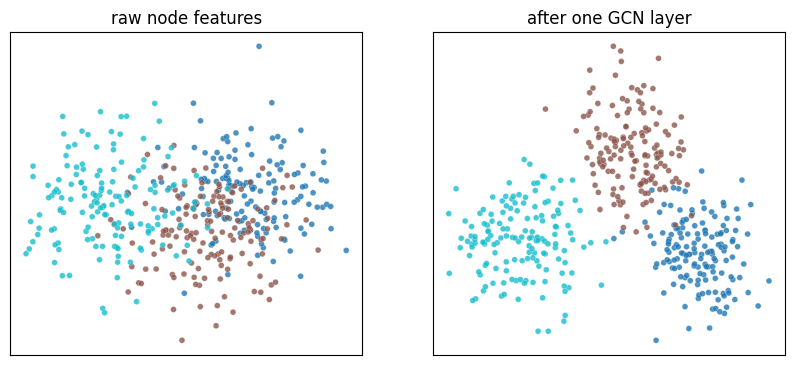

In [3]:
T.set_seed(0)
gcn = M.GNN(data.num_features, 32, int(data.y.max())+1, conv="gcn", n_layers=2)
res = T.train_node(gcn, data, task="classification", epochs=200)
print(f"GCN test accuracy = {res['test_metric']:.3f}  ({res['n_params']} params)")

# Raw features vs learned embeddings, projected to 2-D.
gcn.eval()
with torch.no_grad():
    emb = gcn.convs[0](data.x, data.edge_index)
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
P.scatter_embeddings(data.x, data.y, "raw node features", ax=ax[0])
P.scatter_embeddings(emb,    data.y, "after one GCN layer", ax=ax[1])
plt.show()

## The flip side: GCN *blends* self and neighbours

GCN folds a node and its neighbours into **one** degree-normalised average - there is no
separate self-weight. That's perfect for homophily, but it means GCN **cannot cleanly
separate** "my own feature" from "the neighbour average". Remember the regression task
from notebook 01? GCN struggles with it while SAGE (separate self/neighbour) sails.

In [4]:
rows = []
for lam in [0.0, 2.0]:
    d, _ = G.make_neighbor_aggregation_regression(structure_weight=lam, seed=1)
    T.set_seed(0)
    gcn_r  = T.train_node(M.GNN(d.num_features,32,1,conv="gcn", n_layers=2,dropout=0.0), d, task="regression", epochs=200)
    sage_r = T.train_node(M.GNN(d.num_features,32,1,conv="sage",n_layers=2,dropout=0.0), d, task="regression", epochs=200)
    rows.append({"task": f"neighbour-agg lambda={lam}", "GCN R2": gcn_r["test_metric"], "SAGE R2": sage_r["test_metric"]})

# ...and on the homophily classification task GCN is the right tool:
T.set_seed(0)
gcn_c  = T.train_node(M.GNN(data.num_features,32,int(data.y.max())+1,conv="gcn"),  data, epochs=200)
sage_c = T.train_node(M.GNN(data.num_features,32,int(data.y.max())+1,conv="sage"), data, epochs=200)
rows.append({"task":"SBM homophily (acc)","GCN R2":gcn_c["test_metric"],"SAGE R2":sage_c["test_metric"]})
pd.DataFrame(rows).round(3)

,task,GCN R2,SAGE R2
0,neighbour-agg lambda=0.0,0.275,0.952
1,neighbour-agg lambda=2.0,0.328,0.968
2,SBM homophily (acc),1.000,1.000


## When to reach for GCN

- (+) **Homophilous** node classification with informative features (citation networks,
  community labelling) - it's a strong, cheap, well-understood baseline. *Always try it first.*
- (!) It **blends** self and neighbours: bad when you need to keep the node's own signal
  distinct (use SAGE), and bad under **heterophily** (notebook 07).
- (!) It **over-smooths** when deep - more in notebook 06.

Next: **GraphSAGE**, which keeps a separate self-weight and learns to *sample* neighbours
so it scales to huge graphs.